In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Read data from CSV file
df = pd.read_csv('StudentsPerformance.csv')

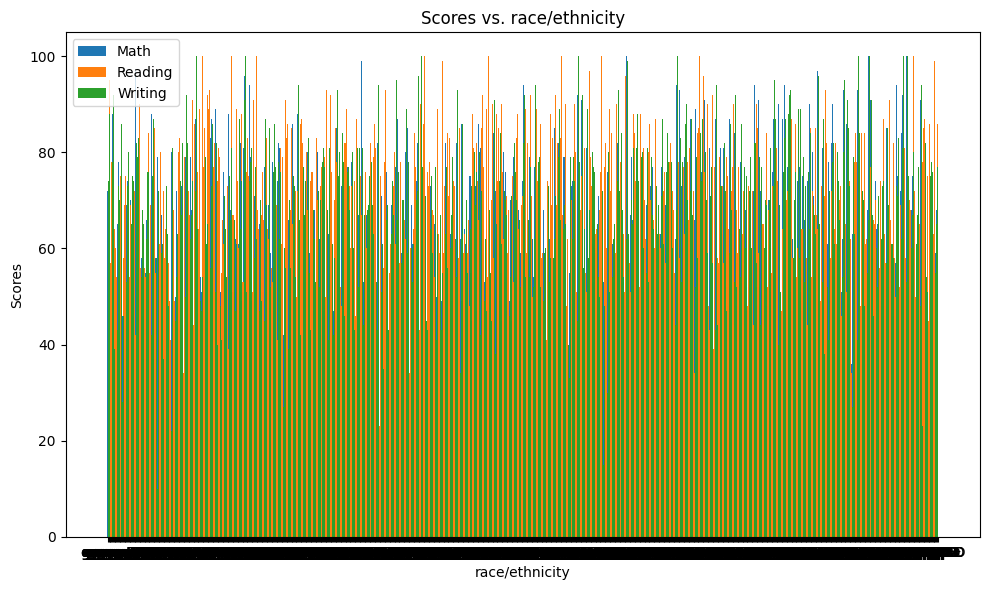

In [7]:
# Plot 1: Bar plot for scores vs. race/ethnicity
plt.figure(figsize=(10, 6))
bar_width = 0.6
index = df.index
labels = df['race/ethnicity']
plt.bar(index - bar_width, df['math score'], bar_width, label='Math')
plt.bar(index, df['reading score'], bar_width, label='Reading')
plt.bar(index + bar_width, df['writing score'], bar_width, label='Writing')
plt.xlabel('race/ethnicity')
plt.ylabel('Scores')
plt.title('Scores vs. race/ethnicity')
plt.xticks(index, labels)
plt.legend()
plt.tight_layout()
plt.show()

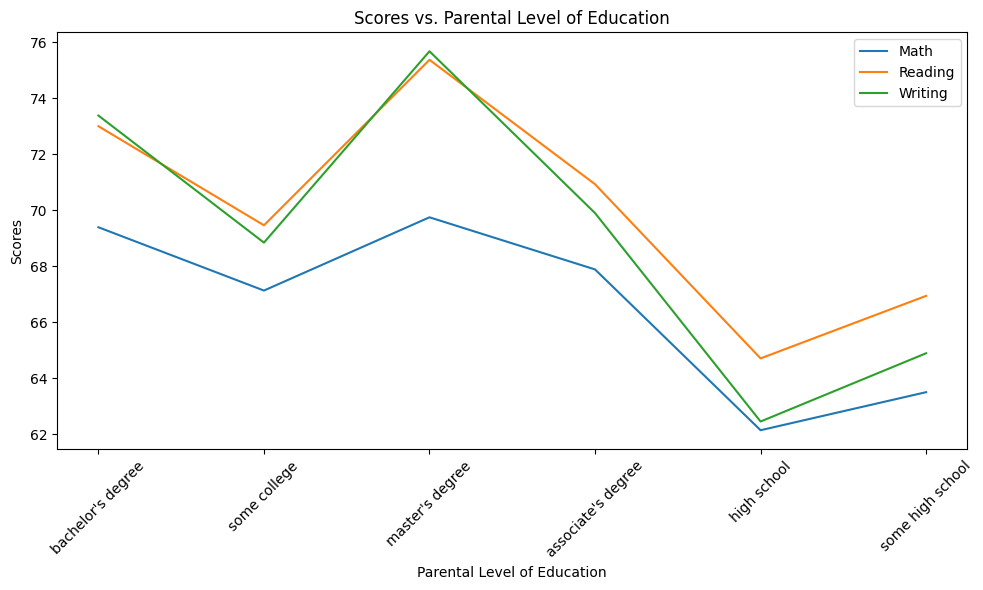

In [9]:
plt.figure(figsize=(10, 6))
education_levels = df['parental level of education'].unique()
scores = []
for subject in ['math score', 'reading score', 'writing score']:
    scores.append([df[df['parental level of education'] == level][subject].mean() for level in education_levels])

for i, score in enumerate(scores):
    plt.plot(education_levels, score, label=['Math', 'Reading', 'Writing'][i])

plt.xlabel('Parental Level of Education')
plt.ylabel('Scores')
plt.title('Scores vs. Parental Level of Education')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import pyodbc as py

# Read the CSV file and filter the data
df = pd.read_csv('studentsperformance.csv')
subset = df[(df["gender"] == "female") & (df["race/ethnicity"] == "group A") & (df["test preparation course"] == "completed")]

# Connect to SQL Server
conn = py.connect('Driver={ODBC Driver 17 for SQL Server};'
                  'Server=LAPTOP-PF51DQF1;'
                  'database=studentsperformance;'
                  'trusted_connection=yes;'
)
cursor = conn.cursor()



In [10]:
for index, row in subset.iterrows():
    cursor.execute("INSERT INTO FemaleScores (gender, race_ethnicity, test_preparation_course, math_score, reading_score, writing_score) VALUES (?, ?, ?, ?, ?, ?)",
                   row["gender"], row["race/ethnicity"], row["test preparation course"], row["math score"], row["reading score"], row["writing score"])
cursor.commit()
cursor.close()

In [11]:
import pandas as pd
data = pd.read_csv('studentsperformance.csv')
df = pd.DataFrame(data)
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
